# 🤖 Análise Preditiva de Conversão e Crescimento da Corretora

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Carregar os dados processados
df_path = Path.cwd().parent / 'Data' / 'PROCESSED' / 'leads_processados_para_pbi.csv'
df = pd.read_csv(df_path, parse_dates=['data_cadastro'])
df.head()


,lead_id,origem,data_cadastro,status_conversao,dias_ate_1o_trade,valor_deposito,perfil,pais,foi_convertido,ano_mes_cadastro
0,2001,Orgânico,2025-03-29,Não Convertido,NaN,0.00,NaN,Brasil,False,2025-03
1,2002,Instagram,2025-03-10,Não Convertido,NaN,0.00,NaN,Portugal,False,2025-03
2,2003,Orgânico,2025-02-20,Convertido,6.0,7985.78,Scalper,Espanha,True,2025-02
3,2004,Facebook,2025-03-13,Convertido,7.0,6026.72,Investidor,Brasil,True,2025-03
4,2005,Orgânico,2025-01-28,Convertido,6.0,4513.74,Investidor,Espanha,True,2025-01


## 📦 Preparação dos Dados para Modelagem

In [3]:
# Copiar o DataFrame base
df_model = df.copy()

# Criar variáveis numéricas de tempo
df_model['mes'] = df_model['data_cadastro'].dt.month
df_model['ano'] = df_model['data_cadastro'].dt.year

# Label target
df_model['convertido'] = df_model['status_conversao'].map({'Convertido': 1, 'Não Convertido': 0})

# Preencher valores nulos
df_model['dias_ate_1o_trade'] = df_model['dias_ate_1o_trade'].fillna(0)
df_model['valor_deposito'] = df_model['valor_deposito'].fillna(0)
df_model['perfil'] = df_model['perfil'].fillna('Desconhecido')

# Eliminar colunas irrelevantes ou problemáticas
colunas_excluir = ['lead_id', 'status_conversao', 'ano_mes_cadastro', 'data_cadastro']
df_model = df_model.drop(columns=[col for col in colunas_excluir if col in df_model.columns])

# Encode de variáveis categóricas
categoricas = df_model.select_dtypes(include=['object']).columns.tolist()
df_model = pd.get_dummies(df_model, columns=categoricas, drop_first=True)

# Separar features e target
X = df_model.drop(columns=['convertido'])
y = df_model['convertido']


## 🧠 Treinamento do Modelo de Classificação

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        48

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



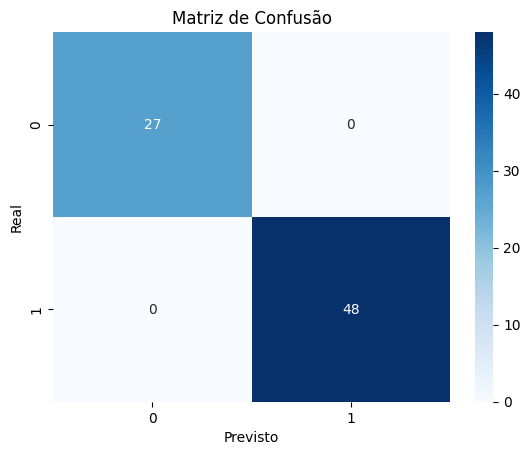

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()


## 🧩 Importância das Variáveis

In [5]:
from sklearn.model_selection import cross_val_score

# Avaliação com validação cruzada (5-fold)
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f"Acurácia média com cross-validation: {scores.mean():.4f}")
print("Scores individuais por fold:", scores)


Acurácia média com cross-validation: 1.0000
Scores individuais por fold: [1. 1. 1. 1. 1.]


In [1]:
!pip install -q shap

  error: subprocess-exited-with-error
  
  × Building wheel for shap (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [260 lines of output]
      Attempting to build SHAP: with_binary=True, with_cuda=True (Attempt 1)
      The nvcc binary could not be located in your $PATH. Either add it to your path, or set $CUDAHOME to enable CUDA.
      Exception occurred during setup, Error building cuda module: TypeError('cannot unpack non-iterable NoneType object')
      Retrying SHAP build without cuda extension...
      Attempting to build SHAP: with_binary=True, with_cuda=False (Attempt 2)
      C:\Users\leojo\AppData\Local\Temp\pip-build-env-445uhaca\overlay\Lib\site-packages\setuptools\config\_apply_pyprojecttoml.py:82: SetuptoolsDeprecationWarning: `project.license` as a TOML table is deprecated
      !!
      
              ********************************************************************************
              Please use a simple string containing a SPDX expression 

In [11]:
import shap

# Criar explicador SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Gráfico de resumo
shap.summary_plot(shap_values[1], X, plot_type="bar")


ModuleNotFoundError: No module named 'shap'

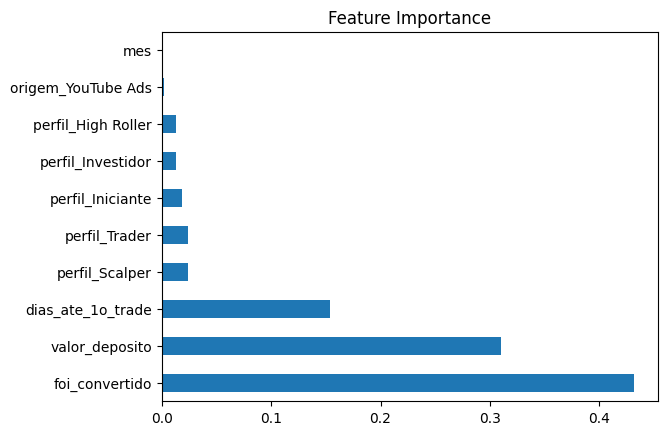

In [6]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Feature Importance")
plt.show()

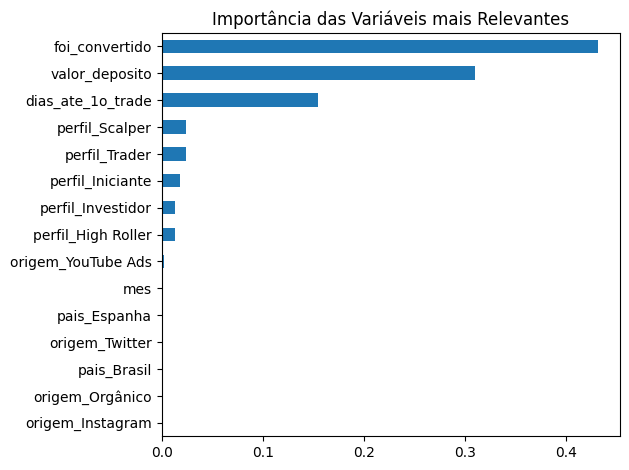

In [7]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(15).plot(kind='barh', title='Importância das Variáveis mais Relevantes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 📈 Previsão de Crescimento dos Leads para os Próximos 6 Meses

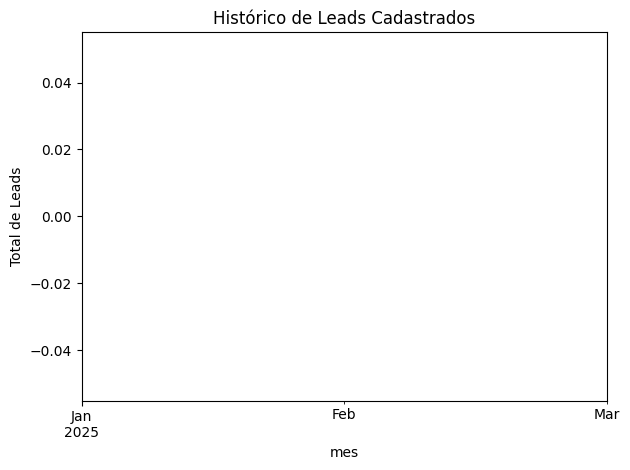

c:\Users\leojo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


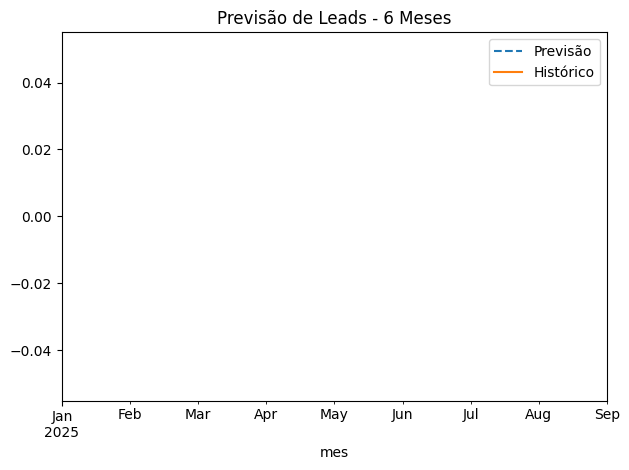

In [10]:
# Reagrupar por mês
df['mes'] = df['data_cadastro'].dt.to_period('M')
lead_trend = df.groupby('mes').size()

# Forecast simples com média móvel
lead_trend.index = lead_trend.index.to_timestamp()
lead_trend = lead_trend.asfreq('M')

lead_trend.plot(title='Histórico de Leads Cadastrados')
plt.ylabel("Total de Leads"); plt.tight_layout(); plt.show()

# Previsão simples para os próximos 6 meses
from statsmodels.tsa.holtwinters import ExponentialSmoothing

modelo = ExponentialSmoothing(lead_trend, trend='add', seasonal=None)
modelo_fit = modelo.fit()
forecast = modelo_fit.forecast(6)

forecast.plot(label='Previsão', style='--')
lead_trend.plot(label='Histórico')
plt.legend(); plt.title('Previsão de Leads - 6 Meses')
plt.tight_layout(); plt.show()


## 💡 Onde Investir Mais: Plataformas com Melhor Custo-Benefício

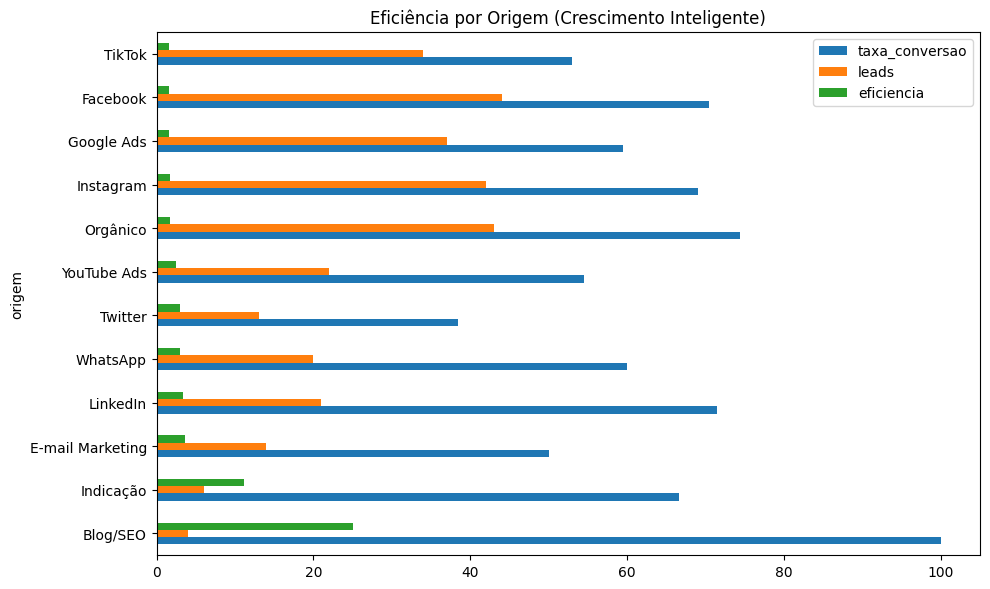

In [11]:
# Conversão por origem
conv_rate = df.groupby('origem')['status_conversao'].value_counts(normalize=True).unstack().fillna(0)
conv_rate['Convertido'] = conv_rate['Convertido'] * 100

# Leads por origem
leads_count = df['origem'].value_counts()

# Combinar tudo
investimento_df = pd.DataFrame({
    'leads': leads_count,
    'taxa_conversao': conv_rate['Convertido']
})

# Índice simples: taxa conversão por volume
investimento_df['eficiencia'] = investimento_df['taxa_conversao'] / investimento_df['leads']
investimento_df.sort_values('eficiencia', ascending=False, inplace=True)

investimento_df[['taxa_conversao', 'leads', 'eficiencia']].plot(kind='barh', figsize=(10,6), title='Eficiência por Origem (Crescimento Inteligente)')
plt.tight_layout(); plt.show()
